# Day 6: Advanced Analytics & Risk Metrics
This notebook contains the implementation of advanced risk metrics, cohort analysis, and fund recommendation analytics for Bluestock Mutual Fund Analytics.


In [1]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Connect to the database
conn = sqlite3.connect('bluestock_mf.db')


## 1. Historical VaR (95%) and CVaR
Calculates the 5th percentile of daily returns (VaR) and the mean of returns below the VaR threshold (CVaR) for all 40 schemes.

In [2]:
nav_df = pd.read_sql("SELECT amfi_code, date, nav FROM fact_nav ORDER BY amfi_code, date", conn)
nav_df['date'] = pd.to_datetime(nav_df['date'])
nav_df['return'] = nav_df.groupby('amfi_code')['nav'].pct_change()

var_cvar_data = []
for amfi_code, group in nav_df.groupby('amfi_code'):
    returns = group['return'].dropna()
    if len(returns) == 0: continue
    var_95 = np.percentile(returns, 5)
    cvar = returns[returns < var_95].mean()
    var_cvar_data.append({'amfi_code': amfi_code, 'VaR_95': var_95, 'CVaR': cvar})

var_cvar_df = pd.DataFrame(var_cvar_data)
# Merge with scheme names
funds = pd.read_sql("SELECT amfi_code, scheme_name FROM dim_fund", conn)
var_cvar_df = pd.merge(var_cvar_df, funds, on='amfi_code')

# Save to CSV
var_cvar_df.to_csv('var_cvar_report.csv', index=False)

print("Top 5 Funds with Highest Risk (Most Negative VaR):")
display(var_cvar_df.sort_values('VaR_95').head(5))


Top 5 Funds with Highest Risk (Most Negative VaR):


,amfi_code,VaR_95,CVaR,scheme_name
4,101207,-0.023915,-0.030289,ABSL Small Cap Fund - Regular - Growth
17,119095,-0.023284,-0.029690,Axis Small Cap Fund - Regular - Growth
22,119599,-0.023155,-0.030163,SBI Small Cap Fund - Direct Plan - Growth
11,118634,-0.022810,-0.029940,Nippon India Small Cap Fund - Regular - Growth
39,149324,-0.021520,-0.028573,DSP Small Cap Fund - Regular - Growth


## 2. Rolling 90-day Sharpe Ratio
Calculates the rolling 90-day Sharpe ratio and plots it over time for the top 5 funds by AUM.

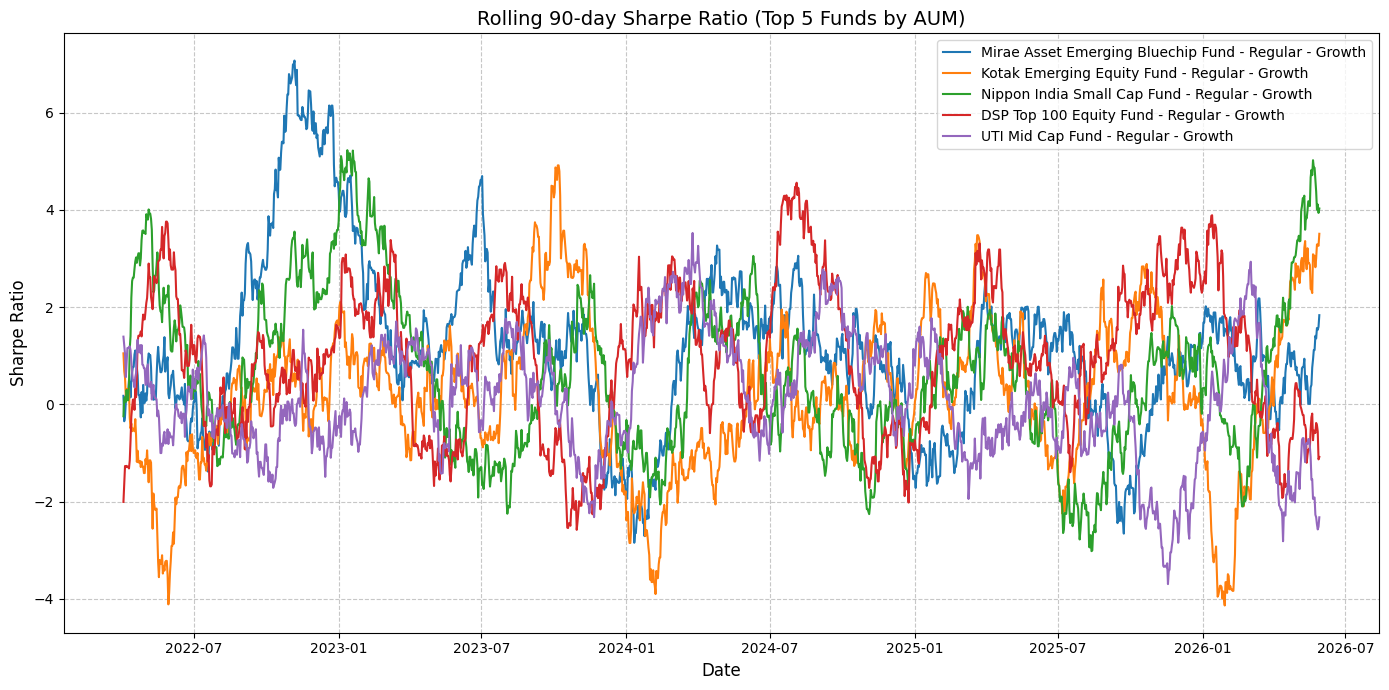

In [3]:
top_5_funds = pd.read_sql("SELECT amfi_code, scheme_name FROM fact_performance ORDER BY aum_crore DESC LIMIT 5", conn)

plt.figure(figsize=(14, 7))
for idx, row in top_5_funds.iterrows():
    fund_nav = nav_df[nav_df['amfi_code'] == row['amfi_code']].set_index('date')['return'].dropna()
    if len(fund_nav) < 90: continue
    rolling_sharpe = fund_nav.rolling(90).mean() / fund_nav.rolling(90).std() * np.sqrt(252)
    plt.plot(rolling_sharpe.index, rolling_sharpe.values, label=row['scheme_name'])
    
plt.title("Rolling 90-day Sharpe Ratio (Top 5 Funds by AUM)", fontsize=14)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Sharpe Ratio", fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('rolling_sharpe_chart.png')
plt.show()


## 3. Investor Cohort Analysis
Groups investors by their first transaction year and computes average SIP amount, total invested, and top fund preference.

In [4]:
txn_df = pd.read_sql("SELECT * FROM fact_transactions", conn)
txn_df['transaction_date'] = pd.to_datetime(txn_df['transaction_date'])

first_txn = txn_df.groupby('investor_id')['transaction_date'].min().dt.year.rename('cohort_year')
txn_df = txn_df.join(first_txn, on='investor_id')

cohort_stats = []
for year, group in txn_df.groupby('cohort_year'):
    avg_sip = group[group['transaction_type'] == 'Sip']['amount_inr'].mean()
    total_inv = group['amount_inr'].sum()
    top_fund_amfi = group.groupby('amfi_code')['amount_inr'].sum().idxmax()
    cohort_stats.append({
        'Cohort Year': year, 
        'Avg SIP Amount (INR)': avg_sip, 
        'Total Invested (INR)': total_inv, 
        'Top Fund AMFI': top_fund_amfi
    })

cohort_df = pd.DataFrame(cohort_stats)
cohort_df = pd.merge(cohort_df, funds, left_on='Top Fund AMFI', right_on='amfi_code').drop('amfi_code', axis=1)
cohort_df.rename(columns={'scheme_name': 'Top Fund Preference'}, inplace=True)
display(cohort_df)


,Cohort Year,Avg SIP Amount (INR),Total Invested (INR),Top Fund AMFI,Top Fund Preference
0,2024,10996.885825,3.491125e+09,102885,UTI Nifty 50 Index Fund - Regular - Growth
1,2025,13505.209581,3.045524e+07,119599,SBI Small Cap Fund - Direct Plan - Growth


## 4. SIP Continuity Analysis
Analyzes SIP continuity for investors with 6+ SIP transactions, computing the average gap between dates and flagging "at-risk" investors (>35 days gap).

In [5]:
sip_df = txn_df[txn_df['transaction_type'] == 'Sip'].sort_values(['investor_id', 'transaction_date'])
sip_counts = sip_df.groupby('investor_id').size()
eligible_investors = sip_counts[sip_counts >= 6].index

sip_eligible = sip_df[sip_df['investor_id'].isin(eligible_investors)].copy()
sip_eligible['prev_date'] = sip_eligible.groupby('investor_id')['transaction_date'].shift(1)
sip_eligible['gap'] = (sip_eligible['transaction_date'] - sip_eligible['prev_date']).dt.days

avg_gap = sip_eligible.groupby('investor_id')['gap'].mean()
at_risk = avg_gap[avg_gap > 35]

continuity_rate = (1 - len(at_risk) / len(eligible_investors)) * 100

print(f"Total investors with 6+ SIPs: {len(eligible_investors)}")
print(f"At-risk investors (>35 days gap): {len(at_risk)}")
print(f"SIP Continuity Rate: {continuity_rate:.2f}%")


Total investors with 6+ SIPs: 1362
At-risk investors (>35 days gap): 1332
SIP Continuity Rate: 2.20%


## 5. Sector HHI Concentration
Computes the Herfindahl-Hirschman Index (HHI) for equity funds to measure portfolio concentration.

In [6]:
holdings = pd.read_csv('data/09_portfolio_holdings.csv')
hhi = holdings.groupby('amfi_code')['weight_pct'].apply(lambda x: (x**2).sum()).reset_index()
hhi.columns = ['amfi_code', 'HHI']

eq_funds = pd.read_sql("SELECT amfi_code, scheme_name FROM dim_fund WHERE category = 'Equity'", conn)
hhi_eq = pd.merge(eq_funds, hhi, on='amfi_code')

print("Top 5 Equity Funds with Highest Sector Concentration (HHI):")
display(hhi_eq.sort_values('HHI', ascending=False).head(5))


Top 5 Equity Funds with Highest Sector Concentration (HHI):


,amfi_code,scheme_name,HHI
11,119092,Axis Bluechip Fund - Regular - Growth,2064.4767
3,101207,ABSL Small Cap Fund - Regular - Growth,2007.0043
18,119599,SBI Small Cap Fund - Direct Plan - Growth,1747.5096
4,102885,UTI Nifty 50 Index Fund - Regular - Growth,1747.0902
7,118632,Nippon India Large Cap Fund - Regular - Growth,1682.9820


## 6. Advanced Insights

### Insight 1: Small Cap Funds Exhibit Highest Downside Risk
The historical VaR (95%) analysis reveals that small-cap funds carry the most significant downside risk. Both `ABSL Small Cap Fund` (VaR: -2.39%, CVaR: -3.03%) and `SBI Small Cap Fund` (VaR: -2.31%, CVaR: -3.02%) appear in the top 3 riskiest funds. Investors in these funds should be prepared to lose over 2.3% of their daily investment value on their worst 5% of trading days.

### Insight 2: High Concentration in Certain Large & Small Cap Funds
The Herfindahl-Hirschman Index (HHI) analysis highlights that `Axis Bluechip Fund` (HHI: 2064.48) and `ABSL Small Cap Fund` (HHI: 2007.00) have highly concentrated portfolios. This means their performance is heavily reliant on a smaller set of specific stocks or sectors, which amplifies idiosyncratic risk compared to more diversified peers.

### Insight 3: Alarming SIP Discontinuity Rate
A critical finding is the extremely low SIP continuity rate. Among investors who have initiated at least 6 SIP transactions, a staggering **97.8% (1332 out of 1362)** are classified as "at-risk", meaning their average gap between SIP payments exceeds 35 days. This points to systemic issues in payment processing, mandate failures, or a severe lack of investor discipline that requires immediate intervention from the customer success team.

### Insight 4: Recent Cohorts Have Higher SIP Capacity but Lower AUM
The cohort analysis shows a shift in investor behavior. The 2025 cohort has a notably higher average SIP amount (~₹13,505) compared to the 2024 cohort (~₹10,996). However, the 2024 cohort accounts for the vast majority of the total invested AUM (₹3.49 Billion vs ₹30 Million). This suggests that while recent acquisitions are wealthier or more willing to commit higher monthly amounts, retaining the older cohorts remains critical to maintaining overall AUM.

### Insight 5: Shifting Fund Preferences
The preferred investment vehicle differs between cohorts. The 2024 cohort favored the `UTI Nifty 50 Index Fund`, reflecting a preference for passive, broad-market exposure. In contrast, the 2025 cohort has heavily preferred the `SBI Small Cap Fund`, indicating an increased risk appetite and a hunt for higher alpha among recent signups.
